In [58]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

In [59]:
df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv')

In [60]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [61]:
# Define the target cks values
target_cks = [
'CK_Tropics',
'CK_Polar Circles',
'CK_Parallels',
'CK_Five Zones',
'CK_Distances between Small Circles'
]

In [62]:
#filtering the df to get the images of the target cks with all their data + printing counts
#(this is why only filter is not enough: we need all the cks that are in other rows with double images values)

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [63]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540          973
cluster_name   3563          119
cks             168           15
place            42           39
printer         166          149
publisher       155          138


In [64]:
print(filtered_df['cks'].dropna().unique())


['CK_Tropics' 'CK_Parallels' 'CK_Five Zones' 'CK_Populated Earth'
 'CK_Seven Climate Zones' 'CK_Terraqueous Globe'
 'CK_Distances between Small Circles' 'CK_Geometry for Geometry'
 'CK_Armillary Sphere' 'CK_Polar Circles' 'CK_Zodiac' 'CK_08 Spheres'
 'CK_Multiple Celestial Circles' 'CK_Right and Oblique Sphere'
 'CK_Movement of the Sun']


In [65]:
# Extract unique values
unique_clusters = filtered_df['cluster_name'].dropna().unique()

# Save to CSV
# pd.Series(unique_clusters).to_csv('/Users/nogashlomi/projects/Image_data/visual_tags/xxx.csv', index=False, header=False)

In [68]:
import pandas as pd

# ------------------------
# Load Excel files
# ------------------------

multi_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles.xlsx')
corr_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/corrected_celestial_circles.xlsx')
geo_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles_geometrical_subjects.xlsx')
five_zones_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/five_zones.xlsx')
# being_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/being_in_a_sign.xlsx')  # optional

# ------------------------
# Ensure key column exists
# ------------------------

assert 'cluster_name' in multi_df.columns
assert 'cluster_name' in corr_df.columns
assert 'cluster_name' in geo_df.columns
assert 'cluster_name' in five_zones_df.columns
# assert 'cluster_name' in being_df.columns
assert 'cluster_name' in filtered_df.columns

# ------------------------
# Base DataFrame from filtered_df
# ------------------------

base_df = filtered_df[['cluster_name']].dropna().drop_duplicates().copy()

# ------------------------
# Merge all visual tag sources
# ------------------------

# Merge with multi_df
visual_tags = pd.merge(
    base_df,
    multi_df,
    on='cluster_name',
    how='left',
    suffixes=('', '_multi')
)

# Merge with corr_df
visual_tags = pd.merge(
    visual_tags,
    corr_df,
    on='cluster_name',
    how='left',
    suffixes=('', '_corr')
)

# Merge with geo_df
visual_tags = pd.merge(
    visual_tags,
    geo_df,
    on='cluster_name',
    how='left',
    suffixes=('', '_geo')
)

# Merge with five_zones_df
visual_tags = pd.merge(
    visual_tags,
    five_zones_df,
    on='cluster_name',
    how='left',
    suffixes=('', '_fivezones')
)

# Optional: merge with being_df
# visual_tags = pd.merge(
#     visual_tags,
#     being_df,
#     on='cluster_name',
#     how='left',
#     suffixes=('', '_being')
# )

# ------------------------
# Resulting DataFrame
# ------------------------

visual_tags


,cluster_name,3D,human figures,material object (double lines),multiple moments,multiple perspectives,color,multiple circles,"decorated or stars, tail, scales",picture,...,type b,type c,type other,seven climes,3D_fivezones,multiple outer circles,eliptic not round,double lines for materiality effect,human figures_fivezones,diagram_fivezones
0,SAC_SIL_00231,no,no,no,no,no,no,no,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SAC_SIL_00287,no,no,no,no,no,no,no,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SAC_SIL_00355,no,no,no,no,no,no,no,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SAC_SIL_01377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,no,no,no,no,no,no,no,no,no,no
4,SAC_SIL_03669,yes,no,no,no,no,no,yes,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,SAC_SIL_03470,no,no,no,no,no,no,no,yes,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,SAC_SIL_02058,yes,no,no,no,no,no,yes,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,SAC_SIL_02532,no,no,no,no,no,no,no,no,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,SAC_SIL_03586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,no,yes,no,no,yes,no,no,yes,no,no


In [69]:
# Columns to check (excluding 'cluster_name' itself)
columns_to_check = visual_tags.columns.difference(['cluster_name'])

# Create a boolean mask for rows where all merge columns are NaN
unmatched_rows = visual_tags[columns_to_check].isna().all(axis=1)

# Get the cluster_names that were not found in any of the 3 Excel files
unmatched_clusters = visual_tags.loc[unmatched_rows, 'cluster_name']

# Print result
if unmatched_clusters.empty:
    print("✅ All cluster_name values from filtered_df were found in at least one of the Excel files.")
else:
    print("❌ Some cluster_name values were not found in any of the Excel files:")
    print(unmatched_clusters.tolist())



✅ All cluster_name values from filtered_df were found in at least one of the Excel files.


In [70]:
VT_2_2_equinoctial_poles = visual_tags
VT_2_2_equinoctial_poles.to_excel('../DATA/04_visual_tags/visual_tags/VT_2.4.xlsx', index=False)
print("Saved VT_2.4 to Excel successfully!")


Saved VT_2.4 to Excel successfully!


In [11]:
import pandas as pd

# Load the Excel files
multi_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles.xlsx')
corr_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/corrected_celestial_circles.xlsx')

# Create sets of cluster names from both files
multi_clusters = set(multi_df['cluster_name'].dropna())
corr_clusters = set(corr_df['cluster_name'].dropna())

# Convert unique_clusters to a Series for analysis
cluster_series = pd.Series(unique_clusters, name='cluster_name')

# Define function to check presence
def check_presence(name):
    in_multi = name in multi_clusters
    in_corr = name in corr_clusters
    if in_multi and in_corr:
        return 'both'
    elif in_multi:
        return 'celestial_circles'
    elif in_corr:
        return 'corrected_celestial_circles'
    else:
        return 'none'

# Apply function to the cluster names
presence_df = cluster_series.to_frame()
presence_df['source'] = presence_df['cluster_name'].apply(check_presence)

# Display the result
print(presence_df)


     cluster_name source
0   SAC_SIL_01833   both
1   SAC_SIL_01259   both
2   SAC_SIL_02829   both
3   SAC_SIL_00756   both
4   SAC_SIL_00197   both
5   SAC_SIL_02742   both
6   SAC_SIL_03037   both
7   SAC_SIL_00647   both
8   SAC_SIL_01222   both
9   SAC_SIL_01085   both
10  SAC_SIL_03700   both
11  SAC_SIL_02028   both
12  SAC_SIL_01439   both
13  SAC_SIL_01783   both
14  SAC_SIL_01033   both
15  SAC_SIL_01137   both
16  SAC_SIL_01305   both
17  SAC_SIL_00929   both
18  SAC_SIL_02737   both
19  SAC_SIL_00226   both
20  SAC_SIL_01086   both
21  SAC_SIL_03471   both
22  SAC_SIL_01867   both
23  SAC_SIL_02248   both


In [150]:
visual_tags = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles_geometrical_subjects.xlsx')

In [151]:
# Get unique values
visual_tags_clusters = set(visual_tags['cluster_name'].unique())
filtered_df_clusters = set(filtered_df['cluster_name'].unique())

# Compare
only_in_visual_tags = visual_tags_clusters - filtered_df_clusters
only_in_filtered_df = filtered_df_clusters - visual_tags_clusters
in_both = visual_tags_clusters & filtered_df_clusters

# Print results
print("Unique cluster names only in visual_tags:")
print(sorted(only_in_visual_tags))

print("\nUnique cluster names only in filtered_df:")
print(sorted(only_in_filtered_df))

# print("\nCluster names present in both:")
# print(sorted(in_both))


Unique cluster names only in visual_tags:
[]

Unique cluster names only in filtered_df:
['SAC_SIL_00016', 'SAC_SIL_00024', 'SAC_SIL_00030', 'SAC_SIL_00094', 'SAC_SIL_00165', 'SAC_SIL_00177', 'SAC_SIL_00197', 'SAC_SIL_00207', 'SAC_SIL_00226', 'SAC_SIL_00231', 'SAC_SIL_00255', 'SAC_SIL_00257', 'SAC_SIL_00259', 'SAC_SIL_00281', 'SAC_SIL_00285', 'SAC_SIL_00287', 'SAC_SIL_00297', 'SAC_SIL_00306', 'SAC_SIL_00313', 'SAC_SIL_00355', 'SAC_SIL_00383', 'SAC_SIL_00403', 'SAC_SIL_00460', 'SAC_SIL_00464', 'SAC_SIL_00467', 'SAC_SIL_00471', 'SAC_SIL_00548', 'SAC_SIL_00554', 'SAC_SIL_00568', 'SAC_SIL_00581', 'SAC_SIL_00602', 'SAC_SIL_00624', 'SAC_SIL_00640', 'SAC_SIL_00647', 'SAC_SIL_00658', 'SAC_SIL_00683', 'SAC_SIL_00699', 'SAC_SIL_00710', 'SAC_SIL_00712', 'SAC_SIL_00755', 'SAC_SIL_00756', 'SAC_SIL_00768', 'SAC_SIL_00778', 'SAC_SIL_00786', 'SAC_SIL_00802', 'SAC_SIL_00809', 'SAC_SIL_00880', 'SAC_SIL_00887', 'SAC_SIL_00888', 'SAC_SIL_00891', 'SAC_SIL_00897', 'SAC_SIL_00898', 'SAC_SIL_00905', 'SAC_SIL_0

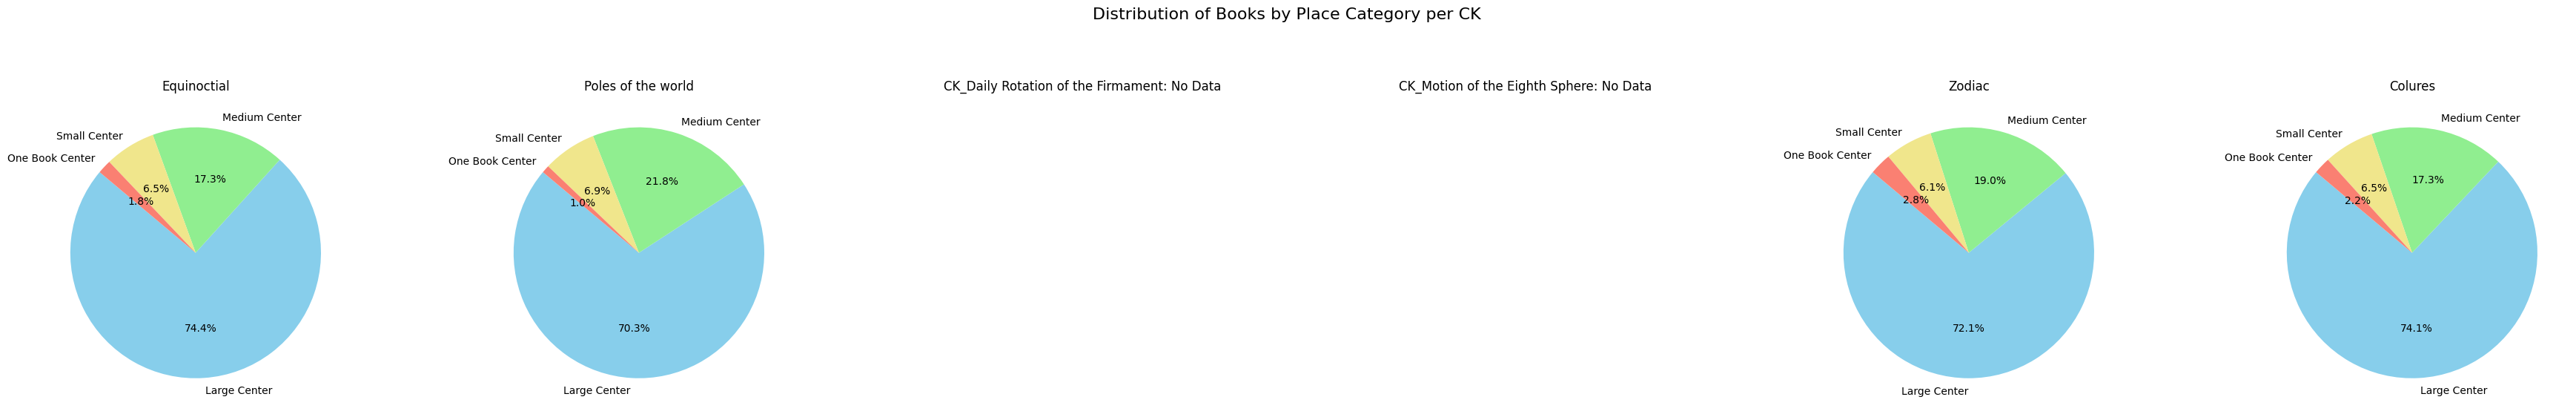

In [99]:
# === Assume filtered_df already filtered to target_cks ===

target_cks = [
 'CK_Equinoctial', 
    'CK_Poles of the world', 
    'CK_Daily Rotation of the Firmament', 
    'CK_Motion of the Eighth Sphere',
    'CK_Zodiac',
    'CK_Colures'
]


# Drop duplicates per (CK, book) — this is the key line
unique_ck_books = filtered_df.drop_duplicates(subset=['cks', 'book'])

# Prepare consistent color map
place_categories = unique_ck_books['place_category'].dropna().unique().tolist()
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki', 'plum', 'orange', 'lightcoral', 'lightsteelblue']
category_color_map = {
    cat: color_palette[i % len(color_palette)] for i, cat in enumerate(place_categories)
}

# Setup plots
num_cks = len(target_cks)
fig, axes = plt.subplots(1, num_cks, figsize=(6 * num_cks, 6))
if num_cks == 1:
    axes = [axes]

# Group by CK after deduplication
grouped = unique_ck_books.groupby('cks')

# Loop through CKs and plot pies
for ax, ck in zip(axes, target_cks):
    if ck in grouped.groups:
        ck_df = grouped.get_group(ck)
        counts = ck_df.groupby('place_category')['book'].nunique().sort_values(ascending=False)
        colors = [category_color_map.get(cat, 'gray') for cat in counts.index]

        ax.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140
        )
        ax.set_title(ck.replace('CK_', '').replace('_', ' '), fontsize=12)
    else:
        ax.set_title(f'{ck}: No Data')
        ax.axis('off')

# Final layout
plt.suptitle('Distribution of Books by Place Category per CK', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.2_pies_place_cat.png', dpi=300)

plt.show()

Number of Unique Books per CK Group, All Books, and Filtered Books:
               CK_Equinoctial  CK_Poles of the world  \
year_interval                                          
1470-1489                 1.0                    1.0   
1490-1509                 7.0                    7.0   
1510-1529                10.0                   11.0   
1530-1549                23.0                    8.0   
1550-1569                58.0                   30.0   
1570-1589                39.0                   26.0   
1590-1609                19.0                   11.0   
1610-1629                11.0                    7.0   
1630-1650                 0.0                    0.0   

               CK_Daily Rotation of the Firmament  \
year_interval                                       
1470-1489                                     0.0   
1490-1509                                     0.0   
1510-1529                                     0.0   
1530-1549                                     0.0 

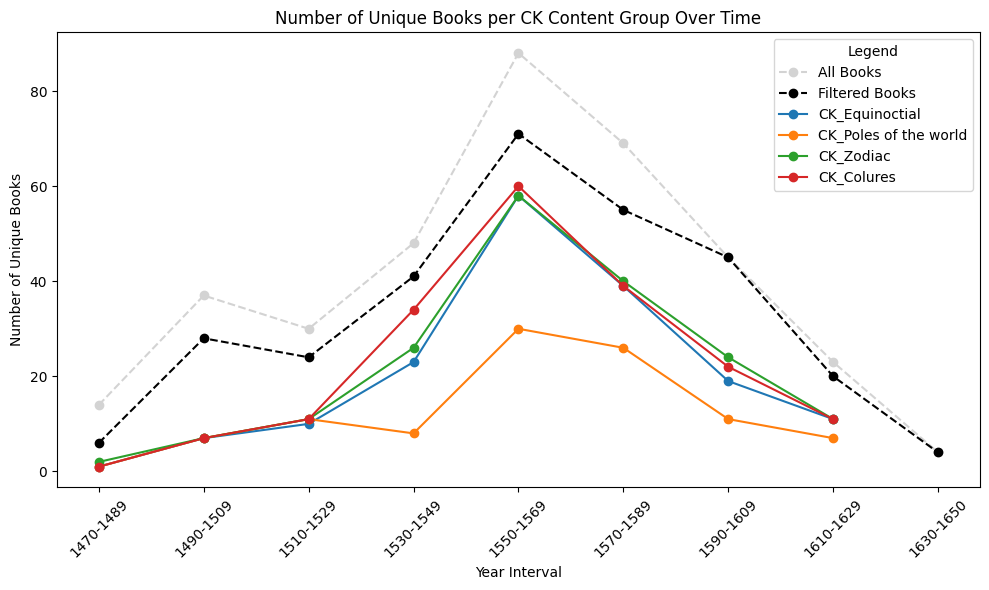

In [100]:

# Define target CK tags
target_cks = [
  'CK_Equinoctial', 
    'CK_Poles of the world', 
    'CK_Daily Rotation of the Firmament', 
    'CK_Motion of the Eighth Sphere',
    'CK_Zodiac',
    'CK_Colures'

]

# ✅ 1. Total books per year_interval (from full books df)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# ✅ 2. Total books per year_interval (from filtered_df)
filtered_books_count = filtered_df.groupby('year_interval', observed=False)['book'].nunique()

# ✅ Use the full timeline from all_books_count
intervals = all_books_count.index.astype(str)

# ✅ 3. Book counts per CK from filtered_df
book_counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# ✅ 4. Create unified DataFrame
book_counts_df = pd.DataFrame(book_counts).reindex(all_books_count.index).fillna(0)
book_counts_df['All Books'] = all_books_count
book_counts_df['Filtered Books'] = filtered_books_count.reindex(all_books_count.index).fillna(0)

# ✅ 5. Print the summary table
print("Number of Unique Books per CK Group, All Books, and Filtered Books:")
print(book_counts_df)

# ✅ 6. Plotting
plt.figure(figsize=(10, 6))

# Plot total number of books (full dataset)
plt.plot(intervals, book_counts_df['All Books'].values, label='All Books', marker='o', color='lightgrey', linestyle='--')

# Plot number of filtered books
plt.plot(intervals, book_counts_df['Filtered Books'].values, label='Filtered Books', marker='o', color='black', linestyle='--')

# Plot each CK content group (only where values are non-zero)
for keyword in target_cks:
    values = book_counts_df[keyword].values
    non_zero_intervals = [intervals[i] for i, val in enumerate(values) if val > 0]
    non_zero_values = [val for val in values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# ✅ 7. Final touches
plt.title('Number of Unique Books per CK Content Group Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()

# ✅ 8. Save the figure
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.2_num_books_cks.png', dpi=300)

# ✅ 9. Show the plot
plt.show()


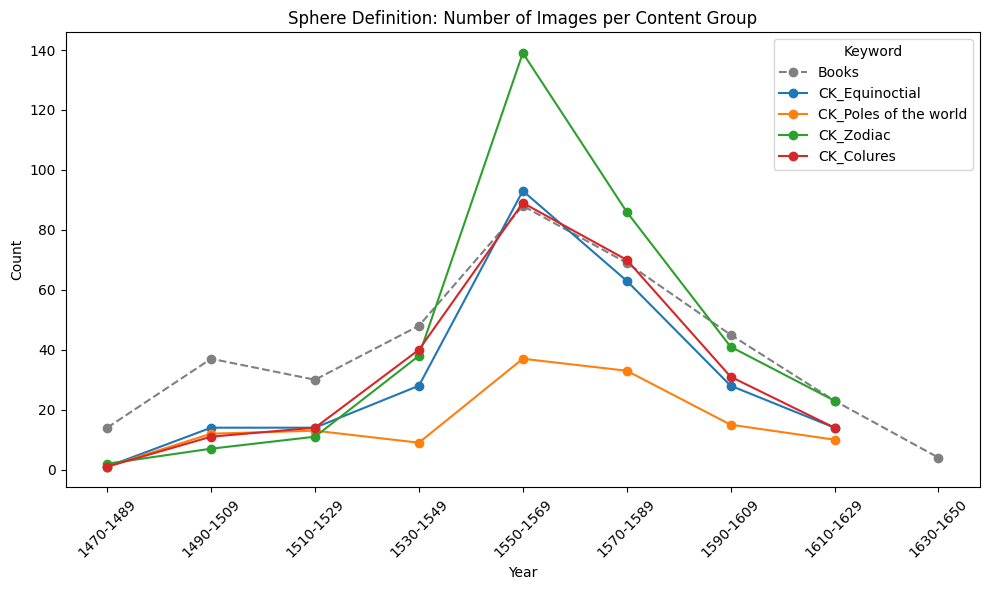

In [101]:
#plot number of images over time from the target cks

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the master timeline from book data
intervals = unique_books_count.index.astype(str)

# Dictionary: {keyword: {interval: unique_image_count}}
counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['images']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# # Create a DataFrame for tabular display (fills in 0 for missing intervals)
# counts_table = pd.DataFrame(counts, index=unique_books_count.index).fillna(0).astype(int)
# print("\n=== Unique Image Counts per CK per Interval ===")
# print(counts_table)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot books
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each keyword (excluding zero values from the line)
for keyword in target_cks:
    data = counts.get(keyword, {})
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]
    non_zero_values = [val for val in keyword_values if val > 0]
    
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Final touches
plt.title('Sphere Definition: Number of Images per Content Group')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Keyword')
plt.tight_layout()

# Save the plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.1_images_cks.png', dpi=300)
plt.show()


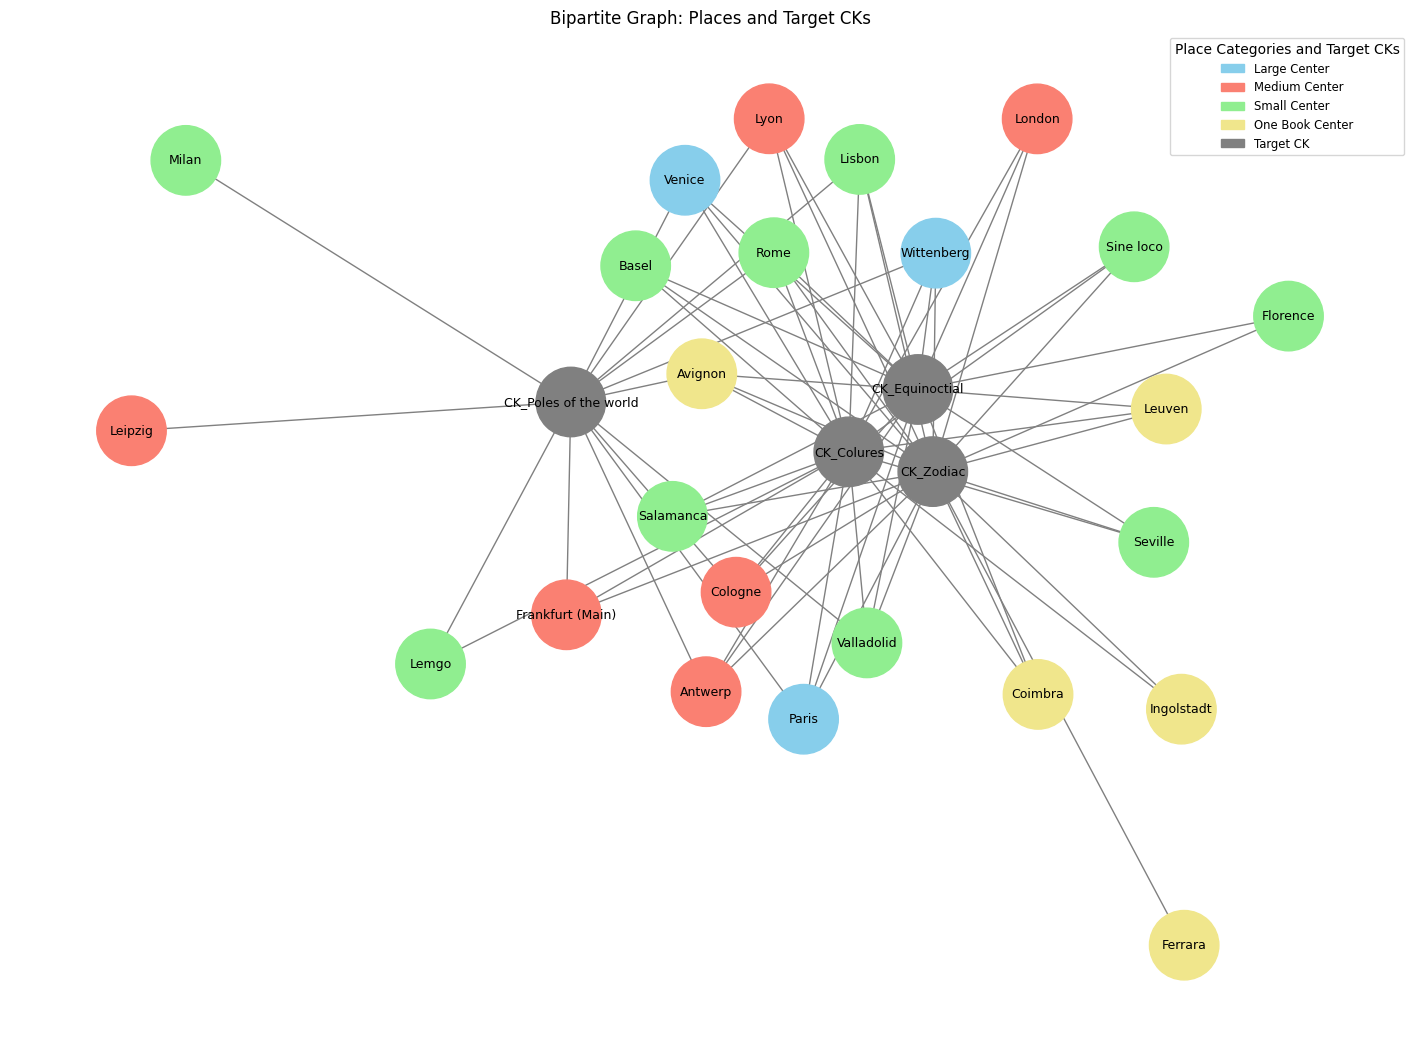

In [102]:
# # target CKs list
# target_cks = [
#    'CK_Equinoctial', 
#     'CK_Poles of the world', 
#     'CK_Daily Rotation of the Firmament', 
#     'CK_Motion of the Eighth Sphere'
# ]

# Use filtered_df instead of visual_df
places = filtered_df['place'].dropna().unique().tolist()

edges = []

for place in places:
    place_data = filtered_df[filtered_df['place'] == place]

    # Add edges only between place and target CK if place_data contains that CK
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

# Unique nodes
places_nodes = list(set(edge[0] for edge in edges))
cks_nodes = list(set(edge[1] for edge in edges))

# Color palette and mapping (places by category)
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = filtered_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in places_nodes:
    cat_series = filtered_df[filtered_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# Build graph
G = nx.Graph()
G.add_nodes_from(places_nodes, bipartite=0)
G.add_nodes_from(cks_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors:
node_colors = []
for node in G.nodes():
    if node in places_nodes:
        node_colors.append(place_color_map.get(node, 'gray'))
    else:
        # target CK nodes colored grey
        node_colors.append('gray')

# Draw graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Legend
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

plt.legend(
    handles=legend_handles,
    title='Place Categories and Target CKs',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs")

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.2_place_network.png', dpi=300)


plt.show()


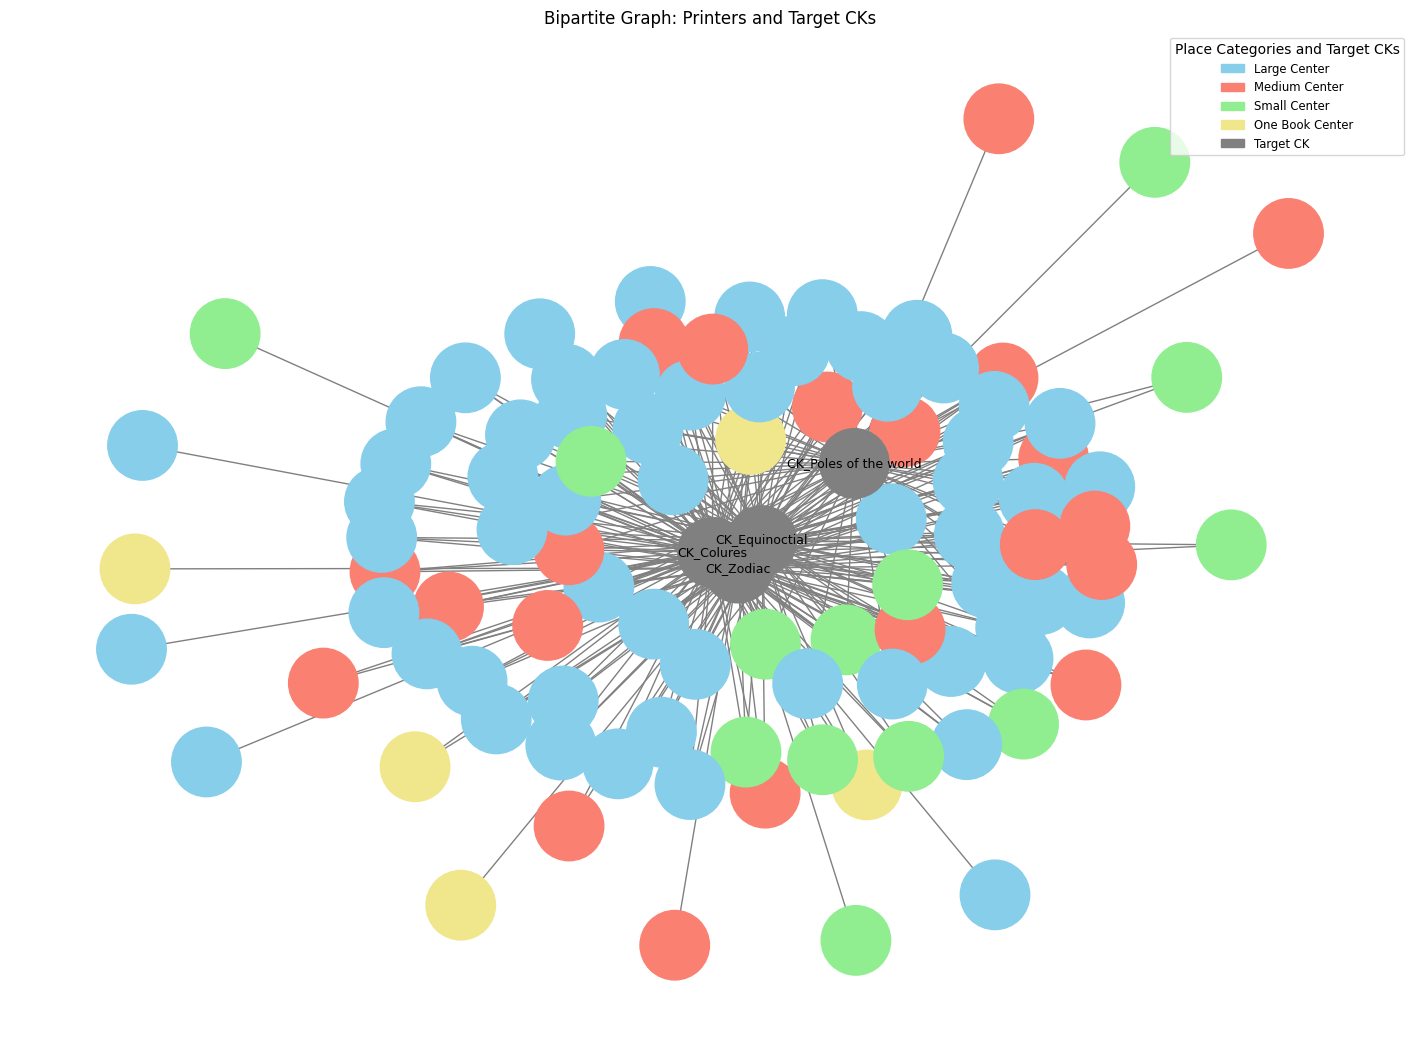

In [103]:
# # target CKs list
# target_cks = [
#     'CK_Equinoctial', 
#     'CK_Poles of the world', 
#     'CK_Daily Rotation of the Firmament', 
#     'CK_Motion of the Eighth Sphere'
# ]

# Use filtered_df instead of visual_df
printers = filtered_df['printer'].dropna().unique().tolist()

edges = []

for printer in printers:
    printer_data = filtered_df[filtered_df['printer'] == printer]

    # Add edges only between printer and target CK if printer_data contains that CK
    for cks in target_cks:
        if (printer_data['cks'] == cks).any():
            edges.append((printer, cks))

# Unique nodes
printer_nodes = list(set(edge[0] for edge in edges))
cks_nodes = list(set(edge[1] for edge in edges))

# Color palette and mapping (printers by place category)
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = filtered_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

printer_color_map = {}
for printer in printer_nodes:
    cat_series = filtered_df[filtered_df['printer'] == printer]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    printer_color_map[printer] = category_color_map.get(category, 'gray')

# Build graph
G = nx.Graph()
G.add_nodes_from(printer_nodes, bipartite=0)
G.add_nodes_from(cks_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors:
node_colors = []
for node in G.nodes():
    if node in printer_nodes:
        node_colors.append(printer_color_map.get(node, 'gray'))
    else:
        # target CK nodes colored grey
        node_colors.append('gray')


# First draw the graph without labels
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=False,  # ✅ No labels here
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)


# Then draw labels only for CK nodes
labels = {node: node for node in cks_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)


# Legend
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

plt.legend(
    handles=legend_handles,
    title='Place Categories and Target CKs',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Printers and Target CKs")

plt.show()


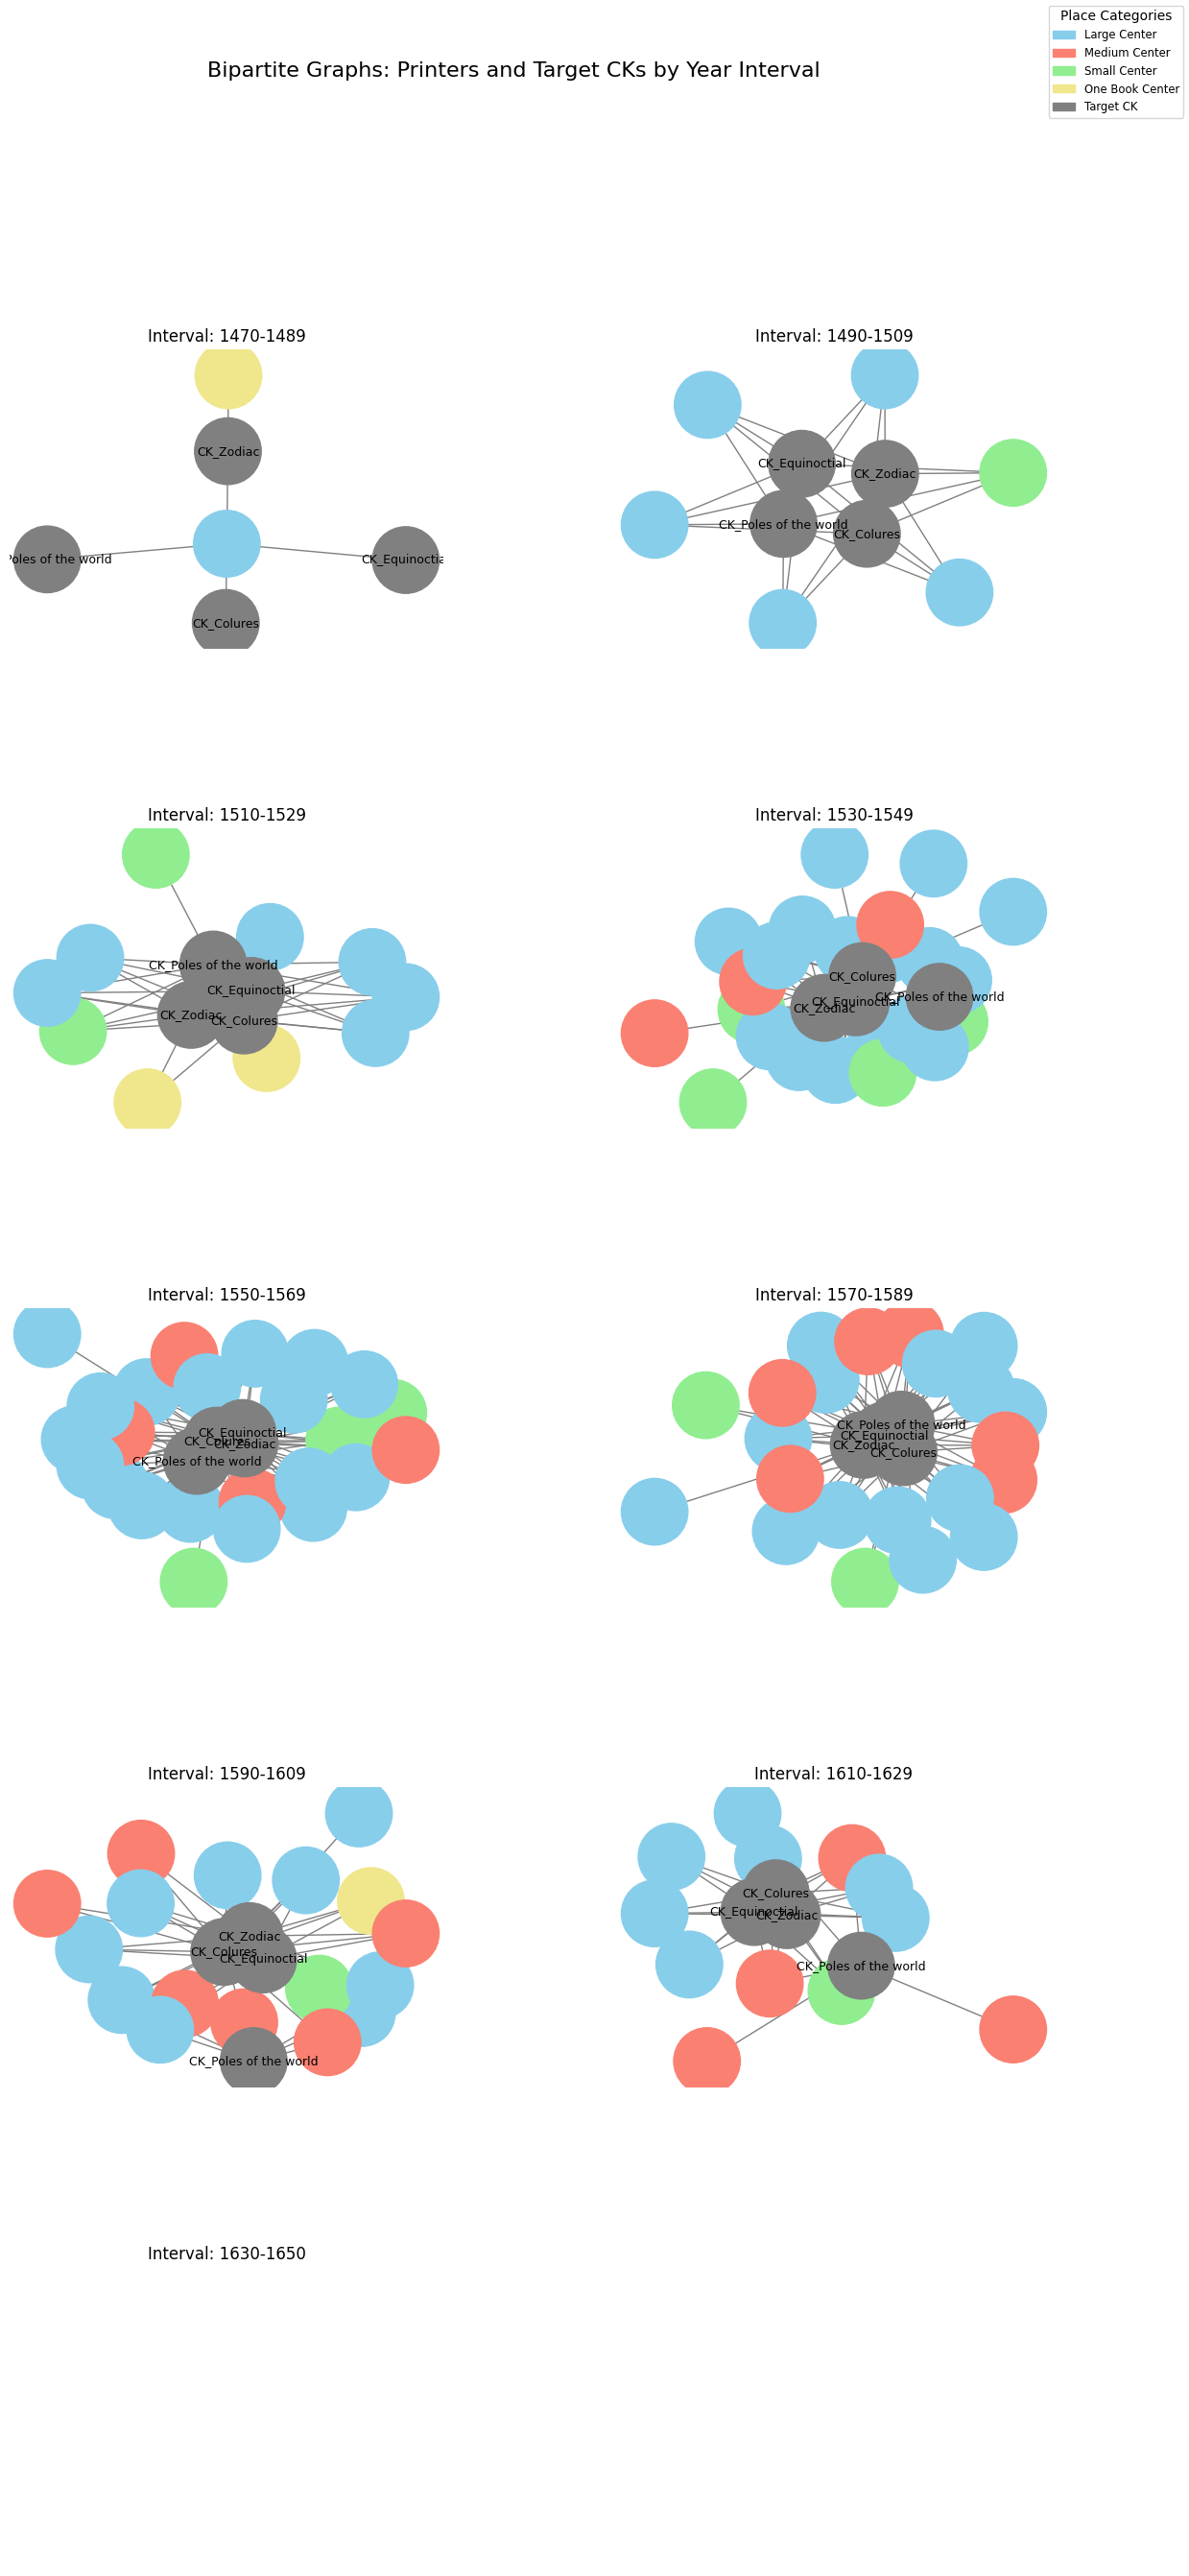

In [104]:


# # === Step 0: Define target CKs ===
# target_cks = [
#     'CK_Equinoctial', 
#     'CK_Poles of the world', 
#     'CK_Daily Rotation of the Firmament', 
#     'CK_Motion of the Eighth Sphere'
# ]

# === Step 1: Color settings ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_categories, color_palette)}

# === Step 2: Get year intervals ===
intervals = sorted(filtered_df['year_interval'].dropna().unique())

# === Step 3: Set up figure ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# === Step 4: Build graph for each interval ===
for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = filtered_df[filtered_df['year_interval'] == interval].copy()
    printers = df_interval['printer'].dropna().unique().tolist()
    edges = []

    for printer in printers:
        printer_data = df_interval[df_interval['printer'] == printer]
        for cks in target_cks:
            if (printer_data['cks'] == cks).any():
                edges.append((printer, cks))

    # Nodes
    printer_nodes = list(set(edge[0] for edge in edges))
    ck_nodes = list(set(edge[1] for edge in edges))

    # Colors
    printer_color_map = {}
    for printer in printer_nodes:
        cat_series = df_interval[df_interval['printer'] == printer]['place_category'].dropna()
        category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
        printer_color_map[printer] = category_color_map.get(category, 'gray')

    node_colors = []
    for node in printer_nodes + ck_nodes:
        if node in printer_nodes:
            node_colors.append(printer_color_map.get(node, 'gray'))
        else:
            node_colors.append('gray')

    # Build graph
    G = nx.Graph()
    G.add_nodes_from(printer_nodes, bipartite=0)
    G.add_nodes_from(ck_nodes, bipartite=1)
    G.add_edges_from(edges)

    pos = nx.spring_layout(G, seed=42, k=0.5)

    # Draw nodes and edges (no labels yet)
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        ax=ax
    )

    # Only label CK nodes
    labels = {node: node for node in ck_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

    ax.set_title(f"Interval: {interval}", fontsize=12)
    ax.axis('off')

# === Step 5: Remove unused axes ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === Step 6: Legend ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

fig.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.suptitle("Bipartite Graphs: Printers and Target CKs by Year Interval", fontsize=16)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_55833/342147188.py:122: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])  # leave space for legend and title


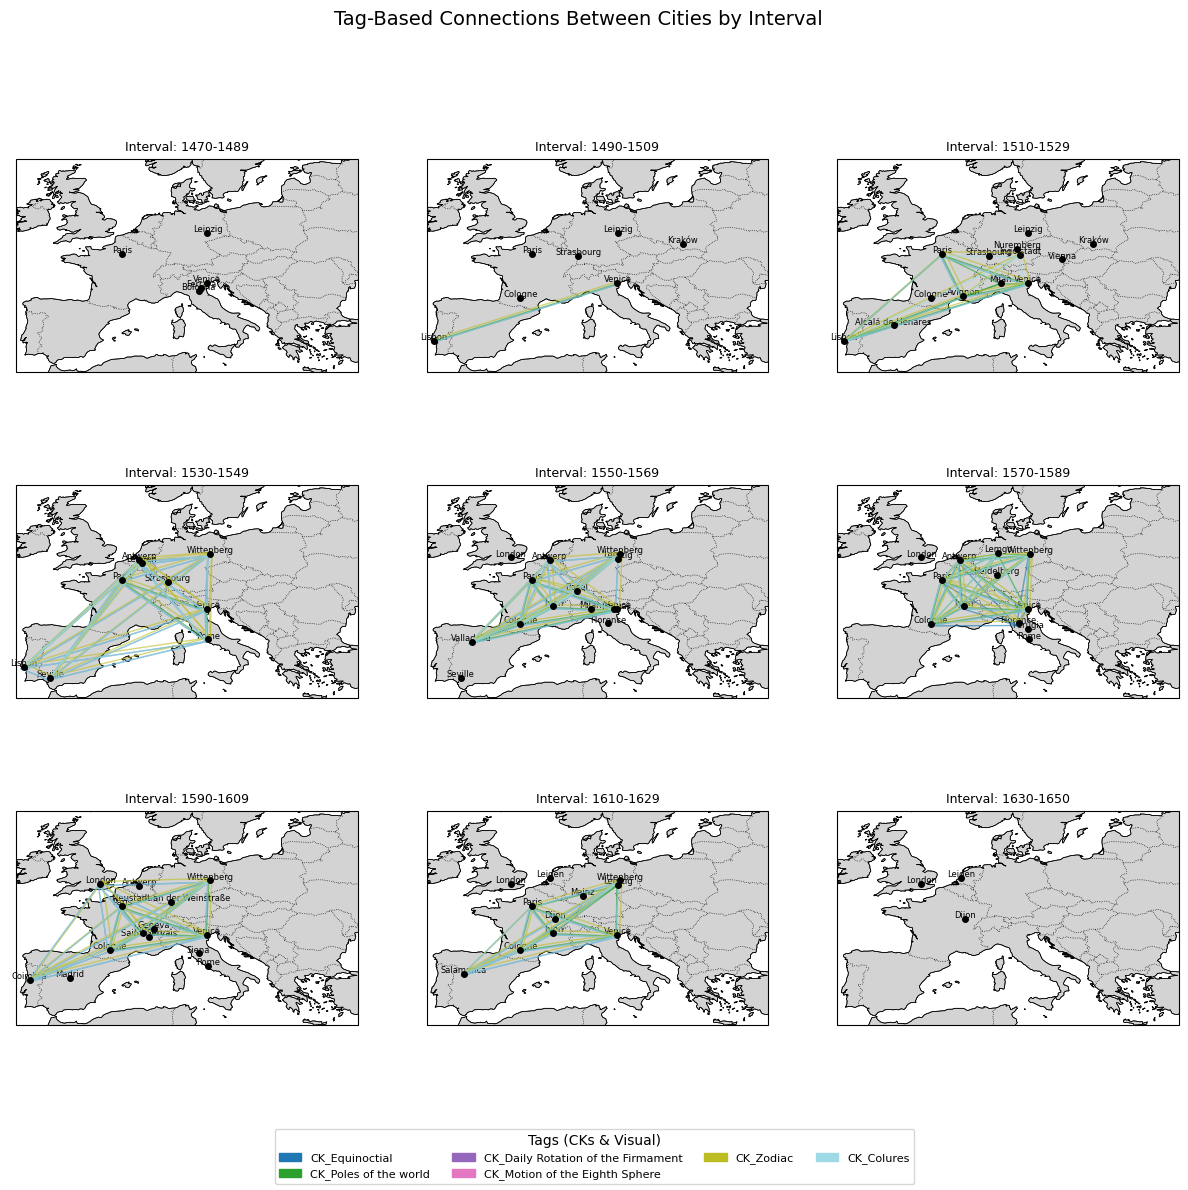

In [105]:
#geotemporal with all cities of the corpus 


# # Replace with your actual CK list
# target_cks = [
#   'CK_Equinoctial', 
#     'CK_Poles of the world', 
#     'CK_Daily Rotation of the Firmament', 
#     'CK_Motion of the Eighth Sphere'
# ]

# Color map
all_tags = target_cks
colors = plt.cm.tab20(np.linspace(0, 1, len(all_tags)))
tag_color_map = dict(zip(all_tags, colors))

# Bounding box
min_lon, max_lon = -10, 30
min_lat, max_lat = 35, 60

# Sorted time intervals
sorted_intervals = sorted(filtered_df['year_interval'].dropna().unique())

# === Function to plot one interval ===
def plot_tag_lines_on_ax(ax, interval):
    df_interval = filtered_df[filtered_df['year_interval'] == interval].copy()

    gdf = gpd.GeoDataFrame(
        df_interval,
        geometry=gpd.points_from_xy(df_interval['longitude'], df_interval['latitude']),
        crs="EPSG:4326"
    ).dropna(subset=['longitude', 'latitude'])

    # All cities from full df
    all_cities_df = df[df['year_interval'] == interval].copy()
    all_cities_df = all_cities_df.dropna(subset=['longitude', 'latitude'])
    all_cities_df = all_cities_df.drop_duplicates(subset=['place'])

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)

    jitter_amount = 0.12

    for tag_index, tag in enumerate(all_tags):
        if tag in target_cks:
            tagged_cities = gdf[gdf['cks'] == tag]
        else:
            tagged_cities = gdf[gdf[tag] == 'yes']

        tagged_coords = tagged_cities[['place', 'longitude', 'latitude']].drop_duplicates()
        jitter_offset = (tag_index % 5 - 2) * jitter_amount

        for (i1, row1), (i2, row2) in combinations(tagged_coords.iterrows(), 2):
            if (row1['longitude'] == row2['longitude']) and (row1['latitude'] == row2['latitude']):
                continue

            ax.plot(
                [row1['longitude'] + jitter_offset, row2['longitude'] + jitter_offset],
                [row1['latitude'] + jitter_offset, row2['latitude'] + jitter_offset],
                color=tag_color_map[tag],
                linewidth=1,
                alpha=0.6,
                transform=ccrs.PlateCarree(),
                zorder=4
            )

    # Plot all city dots
    for _, row in all_cities_df.iterrows():
        ax.plot(
            row['longitude'], row['latitude'],
            marker='o', color='black', markersize=4,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        ax.text(
            row['longitude'], row['latitude'] + 0.15,
            row['place'], fontsize=6, ha='center',
            transform=ccrs.PlateCarree()
        )

    ax.set_title(f"Interval: {interval}", fontsize=9)


# === Plotting pages in 3x3 grid ===
per_page = 9
num_pages = int(np.ceil(len(sorted_intervals) / per_page))

for page in range(num_pages):
    start = page * per_page
    end = min((page + 1) * per_page, len(sorted_intervals))
    intervals_subset = sorted_intervals[start:end]

    fig, axs = plt.subplots(
        3, 3,
        figsize=(15, 12),  # enough space, but tight
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    axs = axs.flatten()

    for i, interval in enumerate(intervals_subset):
        plot_tag_lines_on_ax(axs[i], interval)

    for j in range(len(intervals_subset), 9):
        axs[j].set_visible(False)

    # Shared legend
    legend_handles = [
        mpatches.Patch(color=color, label=tag) for tag, color in tag_color_map.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,
        fontsize=8,
        title='Tags (CKs & Visual)'
    )

    # Title and layout
    plt.suptitle("Tag-Based Connections Between Cities by Interval", fontsize=14)
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])  # leave space for legend and title

    # plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.9_geotemporal.png', dpi=300)

    
    plt.show()



In [106]:

# Load the reference DataFrame
# If your df is in a file, load it like this:
# df = pd.read_excel('your_reference_file.xlsx')
# For now, assuming df is already defined

# Load the three Excel files
geo_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles_geometrical_subjects.xlsx')
multi_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles.xlsx')
corr_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/corrected_celestial_circles.xlsx')

# Define function to get unique cks values per file
def get_cks(file_df, df):
    merged = file_df.merge(df[['cluster_name', 'cks']], on='cluster_name', how='inner')
    return merged['cks'].dropna().unique()

# Apply function to each file
cks_geo = get_cks(geo_df, df)
cks_multi = get_cks(multi_df, df)
cks_corr = get_cks(corr_df, df)

# Print results
print("CKS values in 'celestial_circles_geometrical_subjects.xlsx':", cks_geo)
print("CKS values in 'celestial_circles.xlsx':", cks_multi)
print("CKS values in 'corrected_celestial_circles.xlsx':", cks_corr)


CKS values in 'celestial_circles_geometrical_subjects.xlsx': ['CK_Elevation of the Pole' 'CK_Horizon' 'CK_Right and Oblique Sphere'
 'CK_Relations between Arcs of the Zodiac and the Equinoctial'
 'CK_Armillary Sphere' 'CK_Great and Small Circles Definition'
 'CK_Distances between Small Circles' 'CK_Parallels'
 'CK_Sphericity of the Water Element' 'CK_Centrality of Earth'
 'CK_Inequality of Natural Days']
CKS values in 'celestial_circles.xlsx': ['CK_Multiple Celestial Circles' 'CK_Colures' 'CK_Horizon'
 'CK_Right and Oblique Sphere' 'CK_Sun Lines and Motion'
 'CK_Geometry for Geometry' 'CK_Poles of the world' 'CK_Five Zones'
 'CK_Terraqueous Globe' 'CK_Parallels' 'CK_Zodiac' 'CK_Equinoctial'
 'CK_Elevation of the Pole' 'CK_Seven Climate Zones' 'CK_Meridian'
 'CK_Tropics' 'CK_Polar Circles' 'CK_Celestial Coordinates'
 'CK_Sphere Sliced by the Signs' 'CK_Distances between Small Circles'
 'CK_Armillary Sphere' 'CK_08 Spheres'
 'CK_Geometric Demonstrations for Instruments' 'CK_Signs of the 

In [152]:
import pandas as pd

# Load your reference DataFrame (assumed already loaded as df)
# df = pd.read_excel('your_reference_file.xlsx')

# Load the three Excel files
geo_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles_geometrical_subjects.xlsx')
multi_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/celestial_circles.xlsx')
corr_df = pd.read_excel('/Users/nogashlomi/projects/Image_data/corrected_celestial_circles.xlsx')

# Extract cluster_name sets
geo_clusters = set(geo_df['cluster_name'].dropna())
multi_clusters = set(multi_df['cluster_name'].dropna())
corr_clusters = set(corr_df['cluster_name'].dropna())

# Compute unique and common sets
only_in_geo = geo_clusters - multi_clusters - corr_clusters
only_in_multi = multi_clusters - geo_clusters - corr_clusters
only_in_corr = corr_clusters - geo_clusters - multi_clusters

common_to_all = geo_clusters & multi_clusters & corr_clusters

# Helper function to get cks for a set of cluster_names
def get_cks_for_clusters(clusters, df):
    return df[df['cluster_name'].isin(clusters)][['cluster_name', 'cks']].drop_duplicates()

# Print results
print(f"Unique in 'geometrical_subjects': {len(only_in_geo)}")
print(get_cks_for_clusters(only_in_geo, df), "\n")

print(f"Unique in 'celestial_circles': {len(only_in_multi)}")
print(get_cks_for_clusters(only_in_multi, df), "\n")

print(f"Unique in 'corrected_celestial_circles': {len(only_in_corr)}")
print(get_cks_for_clusters(only_in_corr, df), "\n")

print(f"Common to all 3 files: {len(common_to_all)}")
print(get_cks_for_clusters(common_to_all, df))


Unique in 'geometrical_subjects': 29
        cluster_name                                                cks
79     SAC_SIL_00102  CK_Relations between Arcs of the Zodiac and th...
163    SAC_SIL_00849                           CK_Elevation of the Pole
374    SAC_SIL_00883              CK_Great and Small Circles Definition
397    SAC_SIL_00924                 CK_Distances between Small Circles
741    SAC_SIL_02310  CK_Relations between Arcs of the Zodiac and th...
976    SAC_SIL_02345                 CK_Distances between Small Circles
995    SAC_SIL_01609                           CK_Elevation of the Pole
2186   SAC_SIL_00483                           CK_Elevation of the Pole
2776   SAC_SIL_01508                           CK_Elevation of the Pole
2777   SAC_SIL_01508                                CK_Armillary Sphere
3832   SAC_SIL_00708                           CK_Elevation of the Pole
4080   SAC_SIL_01083                           CK_Elevation of the Pole
4152   SAC_SIL_00322       